In [3]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

from feature_engineering import load_and_merge, engineer_features
from forecast import (encode_cats, time_split, train_xgboost,
                      evaluate, plot_feature_importance, run_arima_baseline)

In [4]:
# -- 1. LOAD & MERGE
df = load_and_merge(
    'data/raw/train.csv',
    'data/raw/store.csv'
)
print(df.head())

Loaded 844,392 open-day records across 1115 stores.
   Store  DayOfWeek       Date  Sales  Customers  Open  Promo StateHoliday  \
1      1          3 2013-01-02   5530        668     1      0            0   
2      1          4 2013-01-03   4327        578     1      0            0   
3      1          5 2013-01-04   4486        619     1      0            0   
4      1          6 2013-01-05   4997        635     1      0            0   
6      1          1 2013-01-07   7176        785     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
1              1         c          a               1270.0   
2              1         c          a               1270.0   
3              1         c          a               1270.0   
4              1         c          a               1270.0   
6              1         c          a               1270.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
1                        9.0            

In [5]:
# -- 2. ENGINEER FEATURES
df = engineer_features(df)
df = encode_cats(df)
print(df.head())

Feature engineering complete. Shape: (813172, 29)
   Store  DayOfWeek       Date  Sales  Customers  Open  Promo  StateHoliday  \
0      1          0 2013-02-04   7032        762     1      1             0   
1      1          1 2013-02-05   6049        678     1      1             0   
2      1          2 2013-02-06   6140        693     1      1             0   
3      1          3 2013-02-07   5499        675     1      1             0   
4      1          4 2013-02-08   5681        630     1      1             0   

   SchoolHoliday  StoreType  ...  Month  Week  IsWeekend  IsMonthStart  \
0              0          2  ...      2     6          0             0   
1              0          2  ...      2     6          0             0   
2              0          2  ...      2     6          0             0   
3              0          2  ...      2     6          0             0   
4              0          2  ...      2     6          0             0   

   IsMonthEnd  Sales_lag_7  Sa

ARIMA Baseline RMSE (Store 1): 3,608.14


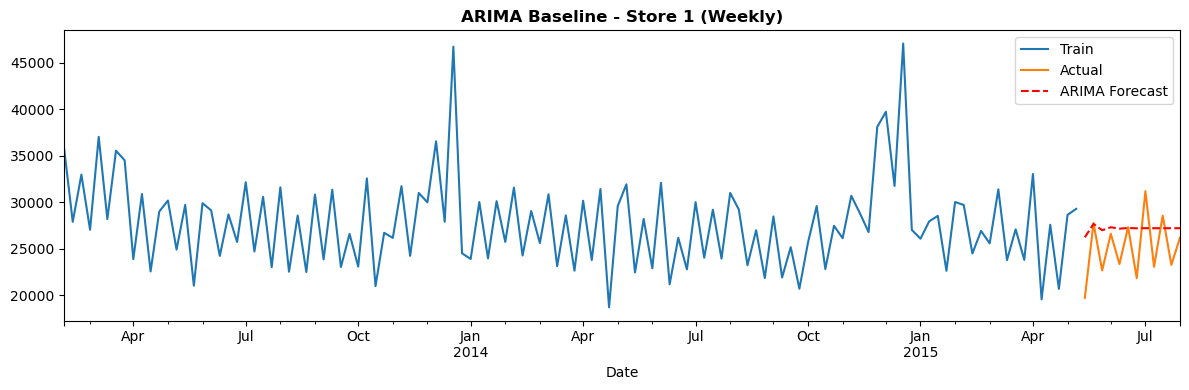

In [6]:
# -- 3. ARIMA BASELINE
run_arima_baseline(df, store_id=1)

In [7]:
# -- 4. TRAIN / TEST SPLIT
train, test = time_split(df, cutoff_date='2015-06-01')

Train: (754561, 29) | Test: (58611, 29)


In [8]:
# -- 5. TRAIN XGBOOST
model = train_xgboost(train)


XGBoost model trained.


Test RMSE : 985.59
Test MAPE : 10.44%


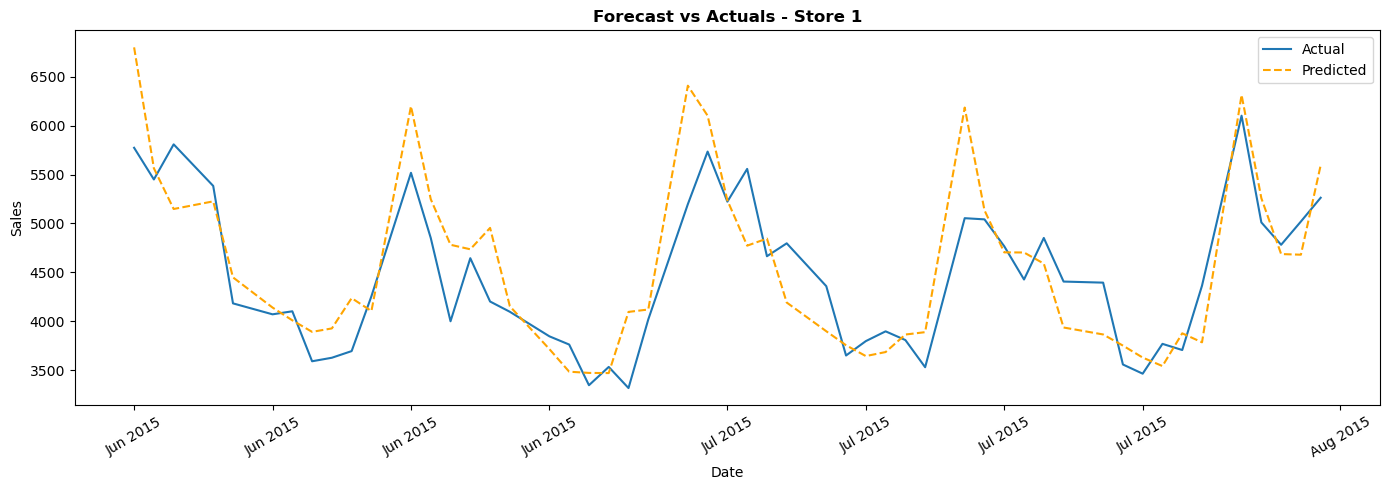

In [9]:
# -- 6. EVALUATE
rmse, mape = evaluate(model, test)

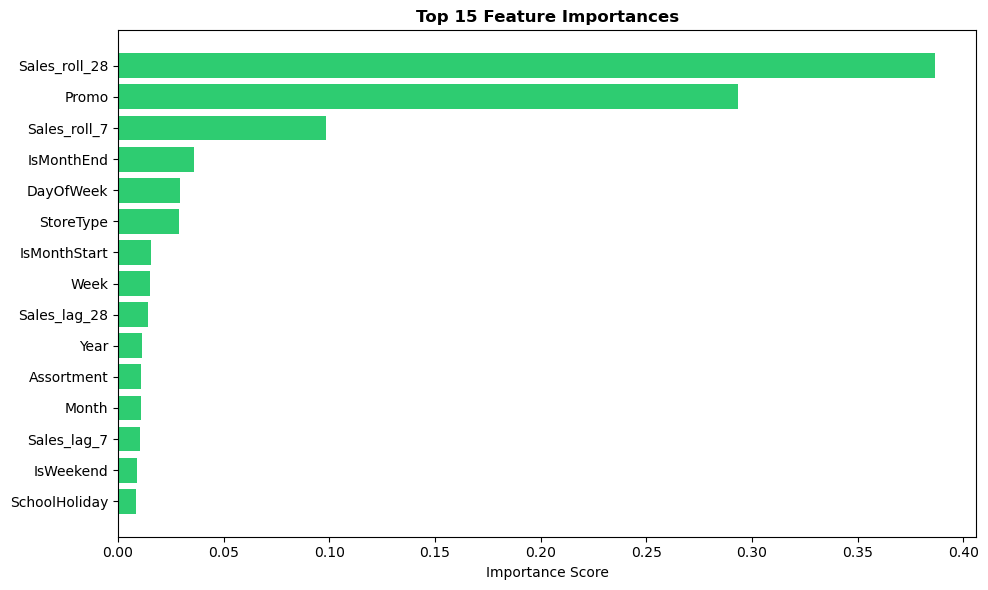

All outputs saved to outputs/


In [10]:
# -- 7. FEATURE IMPORTANCE
plot_feature_importance(model)

print('All outputs saved to outputs/')